<a href="https://colab.research.google.com/github/khushiv-afk/gene-data-analysis/blob/main/genedataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gene Data Analysis

This notebook analyzes gene expression data from a CSV file.
It calculates:
- Average expression
- Highest expression gene
- Lowest expression gene

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crawford/gene-expression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gene-expression' dataset.
Path to dataset files: /kaggle/input/gene-expression


checking files inside csv

In [3]:
import os

files = os.listdir(path)
print(files)

['data_set_ALL_AML_independent.csv', 'data_set_ALL_AML_train.csv', 'actual.csv']


In [4]:
file_path = os.path.join(path, 'gene_expression.csv')
print(file_path)

/kaggle/input/gene-expression/gene_expression.csv


In [6]:
import csv
import os # Added for os.path.join, though 'path' is globally available

def read_gene_data(filename):
    genes = []

    with open(filename, 'r') as file:
        reader = csv.DictReader(file)
        for row in reader:
            genes.append(row)

    return genes

# Fix: Update file_path to use an existing CSV file
# 'path' variable is available from previous cell execution
file_path = os.path.join(path, 'data_set_ALL_AML_train.csv')

data = read_gene_data(file_path)

print(data[:5])   # show first 5 rows

[{'Gene Description': 'AFFX-BioB-5_at (endogenous control)', 'Gene Accession Number': 'AFFX-BioB-5_at', '1': '-214', 'call': 'A', '2': '-139', '3': '-76', '4': '-135', '5': '-106', '6': '-138', '7': '-72', '8': '-413', '9': '5', '10': '-88', '11': '-165', '12': '-67', '13': '-92', '14': '-113', '15': '-107', '16': '-117', '17': '-476', '18': '-81', '19': '-44', '20': '17', '21': '-144', '22': '-247', '23': '-74', '24': '-120', '25': '-81', '26': '-112', '27': '-273', '34': '-20', '35': '7', '36': '-213', '37': '-25', '38': '-72', '28': '-4', '29': '15', '30': '-318', '31': '-32', '32': '-124', '33': '-135'}, {'Gene Description': 'AFFX-BioB-M_at (endogenous control)', 'Gene Accession Number': 'AFFX-BioB-M_at', '1': '-153', 'call': 'A', '2': '-73', '3': '-49', '4': '-114', '5': '-125', '6': '-85', '7': '-144', '8': '-260', '9': '-127', '10': '-105', '11': '-155', '12': '-93', '13': '-119', '14': '-147', '15': '-72', '16': '-219', '17': '-213', '18': '-150', '19': '-51', '20': '-229', '21

In [7]:
import pandas as pd

df = pd.read_csv(file_path)
print(df.head())
print(df.columns)

                      Gene Description Gene Accession Number    1 call    2  \
0  AFFX-BioB-5_at (endogenous control)        AFFX-BioB-5_at -214    A -139   
1  AFFX-BioB-M_at (endogenous control)        AFFX-BioB-M_at -153    A  -73   
2  AFFX-BioB-3_at (endogenous control)        AFFX-BioB-3_at  -58    A   -1   
3  AFFX-BioC-5_at (endogenous control)        AFFX-BioC-5_at   88    A  283   
4  AFFX-BioC-3_at (endogenous control)        AFFX-BioC-3_at -295    A -264   

  call.1    3 call.2    4 call.3  ...   29 call.33   30 call.34   31 call.35  \
0      A  -76      A -135      A  ...   15       A -318       A  -32       A   
1      A  -49      A -114      A  ... -114       A -192       A  -49       A   
2      A -307      A  265      A  ...    2       A  -95       A   49       A   
3      A  309      A   12      A  ...  193       A  312       A  230       P   
4      A -376      A -419      A  ...  -51       A -139       A -367       A   

    32 call.36   33 call.37  
0 -124       A

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv(file_path)

# Select only numeric expression columns
expr_cols = [col for col in df.columns if col.isdigit()]

# Convert them to numeric (important)
df[expr_cols] = df[expr_cols].apply(pd.to_numeric, errors='coerce')

# Calculate average expression for each gene
df['Average_Expression'] = df[expr_cols].mean(axis=1)

# Show top 5 genes with highest expression
top_genes = df.sort_values(by='Average_Expression', ascending=False)

print("Top 5 Highly Expressed Genes:\n")
print(top_genes[['Gene Description', 'Average_Expression']].head())

Top 5 Highly Expressed Genes:

                        Gene Description  Average_Expression
4198           PTB Ribosomal protein L26        25150.052632
1764  RPLP0 Ribosomal protein; large; P0        24140.578947
1221       RPL37A Ribosomal protein L37a        23828.105263
4453  RpS8 gene for ribosomal protein S8        23801.315789
5647     GB DEF = HLA-B null allele mRNA        23647.815789


In [10]:
print("\nLowest Expressed Genes:\n")
print(top_genes[['Gene Description', 'Average_Expression']].tail())


Lowest Expressed Genes:

                                       Gene Description  Average_Expression
1022                   Endothelial Cell Growth Factor 1        -2745.947368
6774  Microtubule-Associated Protein Tau; Alt. Splic...        -2843.263158
6711  MST1 Macrophage stimulating 1 (hepatocyte grow...        -2908.447368
6775                Serine/Threonine Kinase (Gb:Z25424)        -5017.263158
6776         Sry-Related Hmg-Box 12 Protein (Gb:X73039)       -18168.473684


now plot

In [11]:
import matplotlib.pyplot as plt

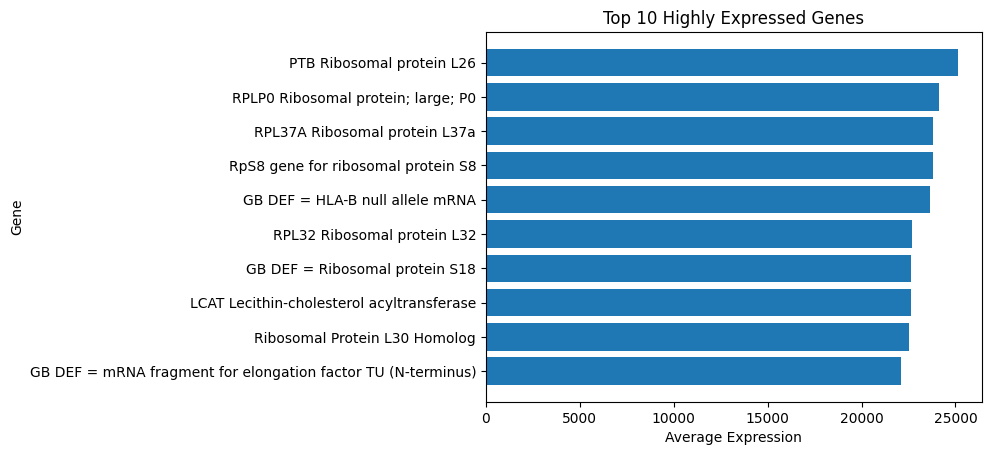

In [12]:
top10 = top_genes.head(10)

plt.figure()
plt.barh(top10['Gene Description'], top10['Average_Expression'])
plt.xlabel("Average Expression")
plt.ylabel("Gene")
plt.title("Top 10 Highly Expressed Genes")

plt.gca().invert_yaxis()  # highest on top
plt.show()

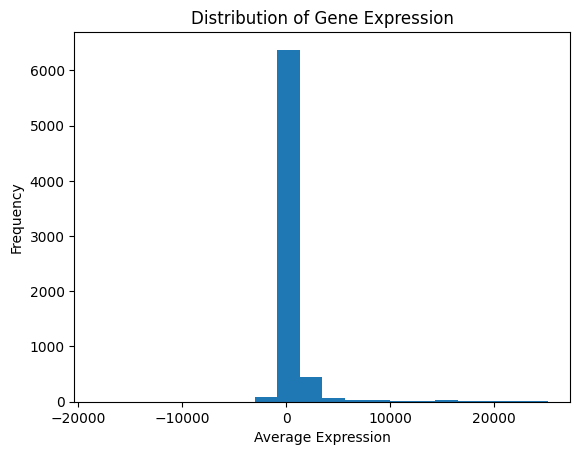

In [13]:
plt.figure()
plt.hist(df['Average_Expression'], bins=20)

plt.xlabel("Average Expression")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression")

plt.show()

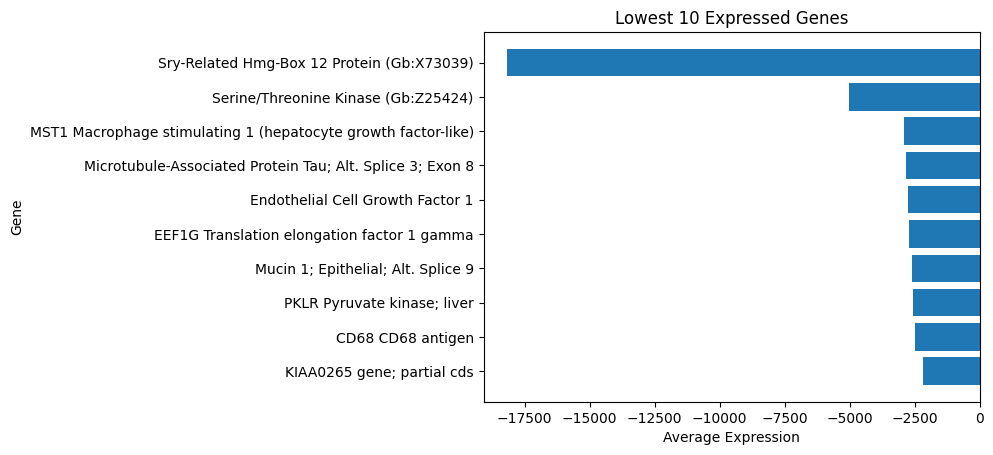

In [15]:
low10 = top_genes.tail(10)

plt.figure()
plt.barh(low10['Gene Description'], low10['Average_Expression'])

plt.xlabel("Average Expression")
plt.ylabel("Gene")
plt.title("Lowest 10 Expressed Genes")

plt.show()
